# 02 Surficial Geology

**Series:** Tribal Soils and Geology

## Surficial Geology of Pine Ridge and Rosebud

Surficial geology describes the unconsolidated materials that cover the
bedrock surface. The Quaternary deposits that form the substrate for soils,
vegetation, infrastructure, and near-surface engineering. On the Missouri
Plateau, these deposits are thin, discontinuous, and closely controlled by
the underlying Pierre Shale.

The primary surficial units on Pine Ridge and Rosebud include:

- **Loess**: wind-deposited silt, up to several meters thick in places.
  Highly erodible. Dominant parent material for soils across the uplands.
- **Alluvium**: stream-deposited sediment in valley bottoms. Variable texture,
  often fine-grained due to the Pierre Shale provenance of most sediment.
- **Colluvium**: slope wash and mass movement deposits. Thick on valley walls
  and escarpments; strongly controlled by Pierre Shale failure behavior.
- **Eolian sand**: dune fields, primarily in the Sandhills transition zone
  near the eastern Rosebud boundary.
- **Residuum**: in-place weathered material directly above bedrock.
  Common on flat upland surfaces where transport energy is low.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import yaml
from shapely.geometry import box
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB,
    REPO_ROOT as _REPO_ROOT, OUTPUTS_DIR, FIGURES_DIR,
    PINE_RIDGE_BBOX, ROSEBUD_BBOX, COMBINED_BBOX, STUDY_BBOX,
)
from src.loaders import (
    load_tribal_boundaries, load_state_geology, load_nhd_flowlines,
)
from src.sovereignty import print_data_acknowledgment, generate_citations, attach_provenance
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT/"config"/"config.yaml") as f:
    CONFIG = yaml.safe_load(f)
TEAL = "#007A6E"; TEAL_LT = "#E0F4F2"; GRAY = "#566573"
def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge", "Rosebud"])
print(f"Environment ready. Primary nations: {len(primary)}")

Environment ready. Primary nations: 2


In [2]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["usgs_state_geology", "census_aiannh"])

TRIBAL SOILS AND GEOLOGY DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin, the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pract

## Load State Geology

In [3]:
# Load South Dakota state geology
# Requires: data/raw/geology/ containing the state geology GDB
# Download from: https://mrdata.usgs.gov/geology/state/

print("Loading South Dakota state geology...")
state_geo = load_state_geology(bbox=STUDY_BBOX)

if state_geo.empty:
    print()
    print("State geology GDB not yet downloaded.")
    print("Download instructions:")
    print("  1. Go to https://mrdata.usgs.gov/geology/state/")
    print("  2. Select South Dakota")
    print("  3. Download the GDB file")
    print("  4. Place in data/raw/geology/")
    print("  5. Re-run this cell")
else:
    print(f"State geology loaded: {len(state_geo):,} features")
    print(f"Columns: {state_geo.columns.tolist()}")
    print(f"CRS: {state_geo.crs}")
    print()
    # Identify the unit name column
    name_col = next((c for c in state_geo.columns
                     if any(k in c.lower() for k in ["unit","name","lith","form","label"])), None)
    if name_col:
        print(f"Unit name column: '{name_col}'")
        print(f"Unique units: {state_geo[name_col].nunique()}")
        print(state_geo[name_col].value_counts().head(15).to_string())

Loading South Dakota state geology...
State geology loaded: 1,285 features
Columns: ['STATE', 'ORIG_LABEL', 'SGMC_LABEL', 'UNIT_LINK', 'REF_ID', 'GENERALIZE', 'SRC_URL', 'URL', 'geometry', 'state', 'orig_label', 'map_sym1', 'map_sym2', 'prov_no', 'province', 'unit_name', 'unit_age', 'unitdesc', 'strat_unit', 'unit_com', 'map_ref', 'rocktype1', 'rocktype2', 'rocktype3', 'unit_ref', 'map_symb2']
CRS: EPSG:4326

Unit name column: 'ORIG_LABEL'
Unique units: 55
ORIG_LABEL
Qt      224
Qal      63
Jms      61
TrPs     60
Kms      56
OCwd     56
MDpe     50
Tw       42
PPm      39
Kfl      36
Pmo      34
Kp       33
Kb       31
Xh       29
Qe       28


## Clip to Study Area and Identify Surficial Units

In [4]:
if not state_geo.empty:
    # Clip to combined Pine Ridge and Rosebud bbox
    clip_box = box(*COMBINED_BBOX)
    geo_clip  = state_geo[state_geo.geometry.intersects(clip_box)].copy()
    print(f"Features intersecting combined study area: {len(geo_clip)}")

    # Calculate area of each unit within the study area
    geo_clip_proj = geo_clip.to_crs(CRS_PROJECTED)
    geo_clip["area_km2"] = geo_clip_proj.geometry.area / 1e6

    # Identify the label/unit column
    unit_col = next((c for c in geo_clip.columns
                     if any(k in c.lower() for k in ["unit","label","sym","lith"])), None)
    if unit_col:
        unit_summary = (geo_clip.groupby(unit_col)["area_km2"]
                        .sum().sort_values(ascending=False).reset_index())
        unit_summary.columns = [unit_col, "area_km2"]
        unit_summary["pct"] = (unit_summary["area_km2"] /
                                unit_summary["area_km2"].sum() * 100).round(1)
        print("\nSurficial unit areas in study area:")
        print(unit_summary.head(15).to_string(index=False))
else:
    print("Load state geology data first (see cell above).")

Features intersecting combined study area: 230

Surficial unit areas in study area:
ORIG_LABEL    area_km2  pct
       Qal 3135.261440 38.2
        Kp 1612.607434 19.7
       PPm  833.820726 10.2
       Kfl  534.965724  6.5
        Qe  316.838923  3.9
        Tw  315.317123  3.8
        Xq  291.878502  3.6
       Pmo  229.085897  2.8
      TrPs  150.445539  1.8
      MDpe  137.459624  1.7
       Xgw  123.958669  1.5
        Qt  111.611235  1.4
        Xh   93.039705  1.1
       Jms   60.583771  0.7
        Kc   57.222987  0.7


## Surficial Geology Map

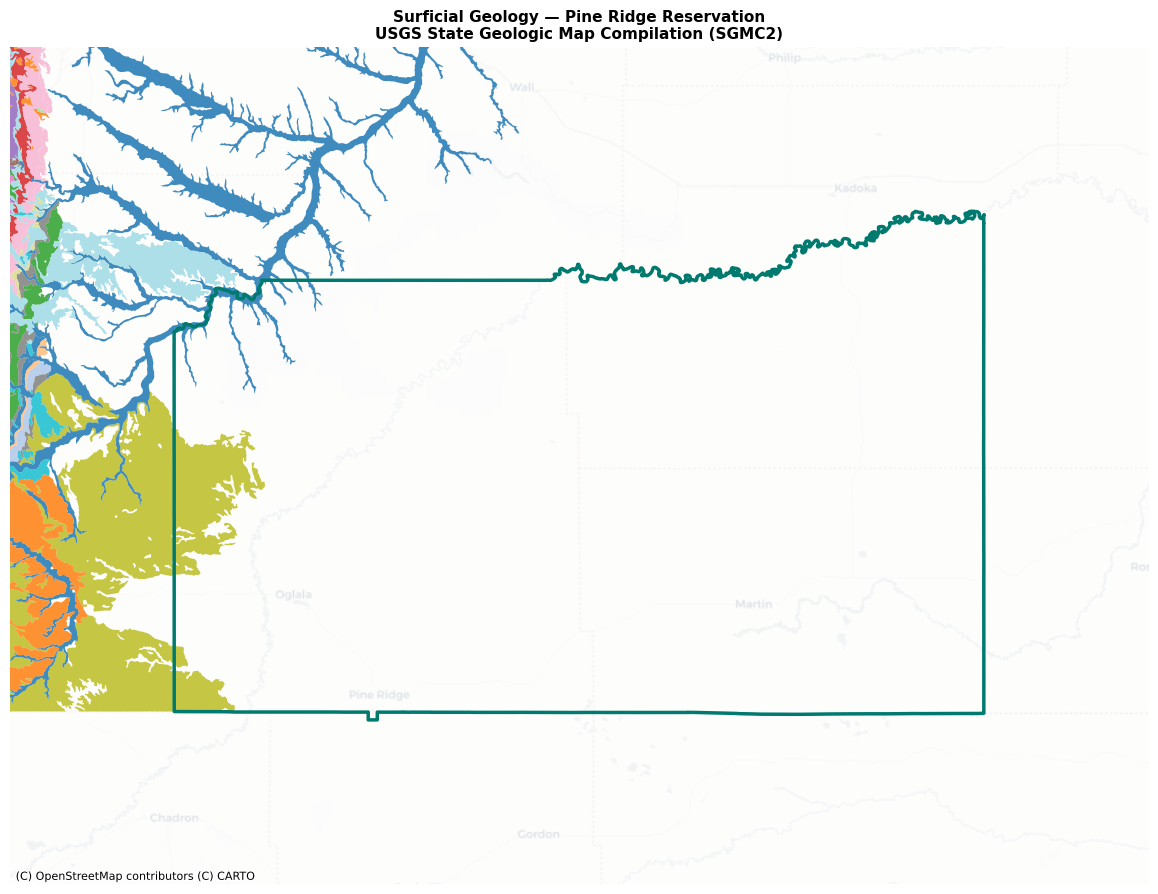

In [12]:
if not state_geo.empty:
    unit_col = "unit_name" if "unit_name" in state_geo.columns else "GENERALIZE"
    nation_boundary_web = nation_boundary[
        nation_boundary["common_name"].str.contains("Oglala")
    ].to_crs(CRS_WEB)

    fig, ax = plt.subplots(1, 1, figsize=(12, 9))

    # Plot all geology — no clipping
    state_geo.to_crs(CRS_WEB).plot(
        ax=ax, column=unit_col, categorical=True,
        alpha=0.85, legend=False, cmap="tab20"
    )

    # Reservation boundary on top
    nation_boundary_web.plot(
        ax=ax, facecolor="none", edgecolor=TEAL,
        linewidth=2.5, zorder=5
    )

    # Set extent from reservation with generous margin to show context
    minx, miny, maxx, maxy = nation_boundary_web.total_bounds
    margin = 40_000   # 40 km — enough to show surrounding geology
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                        alpha=0.3, zoom=9)
    except Exception:
        pass

    ax.set_axis_off()
    ax.set_title(
        "Surficial Geology — Pine Ridge Reservation\n"
        "USGS State Geologic Map Compilation (SGMC2)",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "02_surficial_geology.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("State geology not loaded — download data and re-run notebook.")

In [10]:
print("Reservation bounds (WGS84):", nation_boundary.total_bounds)
print("Geology clip bounds (WGS84):", geo_sub.total_bounds if not geo_sub.empty else "empty")
print("Geology feature count:", len(geo_sub))
print("PINE_RIDGE_BBOX:", PINE_RIDGE_BBOX)

Reservation bounds (WGS84): [-103.00102602   42.98736197 -101.22733473   43.79673864]
Geology clip bounds (WGS84): [-104.05599349   43.0000659  -101.24790552   45.14331241]
Geology feature count: 230
PINE_RIDGE_BBOX: (-103.5, 42.5, -101.5, 43.8)


## Surficial Units and Their Significance

In [6]:
# Summary table of surficial unit significance for Tribal land management
# This information is consistent with published USGS mapping
# Tribal resource managers should review with local knowledge

surficial_significance = [
    ("Loess",
     "Highly erodible when vegetative cover is disturbed. "
     "Primary upland soil parent material. Thickness controls "
     "available water capacity for plant growth."),
    ("Alluvium",
     "Valley bottoms have highest agricultural potential. "
     "Flood risk. Often contains shallow perched groundwater. "
     "Culturally significant riparian corridors."),
    ("Colluvium",
     "Mass movement and slope wash deposits. Often unstable. "
     "Pierre Shale colluvium creates shrink-swell soil conditions. "
     "Infrastructure siting should avoid thick colluvium."),
    ("Eolian sand",
     "Sandhills transition zone (eastern Rosebud). "
     "High infiltration, good for groundwater recharge. "
     "Unstable if vegetation is removed."),
    ("Residuum",
     "Weathered bedrock in place. Properties inherited from "
     "underlying unit. Pierre Shale residuum = expansive clay. "
     "Sandstone residuum = sandy, well-drained."),
    ("Glacial deposits",
     "Limited extent in study area (southern extent of glaciation). "
     "Where present, may include till with transported boulders "
     "and finer-grained glaciolacustrine deposits."),
]

print("SURFICIAL UNIT SIGNIFICANCE for Pine Ridge and Rosebud")
for unit, sig in surficial_significance:
    print(f"\n{unit}")
    print(f"  {sig}")

SURFICIAL UNIT SIGNIFICANCE for Pine Ridge and Rosebud

Loess
  Highly erodible when vegetative cover is disturbed. Primary upland soil parent material. Thickness controls available water capacity for plant growth.

Alluvium
  Valley bottoms have highest agricultural potential. Flood risk. Often contains shallow perched groundwater. Culturally significant riparian corridors.

Colluvium
  Mass movement and slope wash deposits. Often unstable. Pierre Shale colluvium creates shrink-swell soil conditions. Infrastructure siting should avoid thick colluvium.

Eolian sand
  Sandhills transition zone (eastern Rosebud). High infiltration, good for groundwater recharge. Unstable if vegetation is removed.

Residuum
  Weathered bedrock in place. Properties inherited from underlying unit. Pierre Shale residuum = expansive clay. Sandstone residuum = sandy, well-drained.

Glacial deposits
  Limited extent in study area (southern extent of glaciation). Where present, may include till with transported 

## Data Status and Gaps

The South Dakota state geologic map provides a useful regional overview of
surficial geology, but map unit boundaries on Pine Ridge and Rosebud may not
reflect local complexity. Several limitations are worth documenting:

**Scale mismatch:** State-scale mapping (1:500,000 or smaller) cannot
resolve the fine-scale variability in loess thickness, colluvial deposits,
or alluvial terrace sequences that matters for infrastructure siting and
soil management.

**Sampling density:** The underlying observations that informed state-scale
mapping are concentrated along road corridors and areas of previous study.
Reservation lands are frequently undersampled.

**Field observation template:** The `data/templates/field_observation_template.xlsx`
provides a standardized format for Tribal geoscientists to collect surficial
geology observations that supplement and refine the state mapping.

These limitations are addressed in notebook 09 (Data Gaps and Sovereignty).

In [7]:
# Print citations
print(generate_citations(["usgs_state_geology", "census_aiannh"]))

DATA CITATIONS

USGS Mineral Resources South Dakota State Geologic Map
  US Geological Survey, Mineral Resources Online Spatial Data. State Geologic Map Compilation. https://mrdata.usgs.gov/geology/state/
  https://mrdata.usgs.gov/geology/state/
  Steward: US Geological Survey | License: Public domain

US Census Bureau TIGER/Line AIANNH Boundaries
  US Census Bureau. TIGER/Line Shapefiles: American Indian / Alaska Native / Native Hawaiian Areas (AIANNH). https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
  https://www.census.gov/geographies/mapping-files/
  Steward: US Census Bureau | License: Public domain

TERRITORIAL PROVENANCE
  1868 Fort Laramie Treaty Oceti Sakowin territory, including the Great Sioux Reservation
  The lands of Pine Ridge and Rosebud Reservations are the sovereign territory of the Oglala Lakota and Sicangu Lakota peoples respectively. Federal and state geological surveys conducted on these lands do not transfer authority over su